In [ ]:

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/FunSearch_enhancement

!pip install openai python-dotenv scipy numpy

Mounted at /content/drive
/content/drive/MyDrive/FunSearch_Project


In [ ]:
import os

os.environ["OPENROUTER_API_KEY"] = "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"

os.environ["LLM_MODEL"] = "arcee-ai/trinity-large-preview:free"



In [ ]:
!python run.py

Running FunSearch from: /content/drive/MyDrive/FunSearch_Project
Specification: specification_nonsymmetric_admissible_set.txt
Test Inputs: [(8, 4), (12, 7)]
DEBUG: Raw generated code:
'  return 0.0'
DEBUG: Wrapped code for parsing:
def fake_function_header():
  return 0.0
DEBUG: Function end line detected: 2
DEBUG: Extracted body lines:
['  return 0.0']
Prompt sent to LLM:
---
"""Generating maximal admissible sets of different dimensionalities."""
import itertools
import numpy as np


def priority_v0(el: tuple[int, ...], n: int, w: int) -> float:
  """Trivial scoring function.

  Args:
    el: an element to be potentially added to the current admissible set.
    n: dimensionality of admissible set.
    w: weight of admissible set.

  Returns:
    A number reflecting the priority with which we want to add `el` to the set.
  """
  return 0.0


def priority_v1(el: tuple[int, ...], n: int, w: int) -> float:
  """Improved version of `priority_v0`.
INSTRUCTIONS:
1. Analyze the previous heuri

✅ 图表已保存至: /content/drive/MyDrive/FunSearch_Project/experiment_plot.png


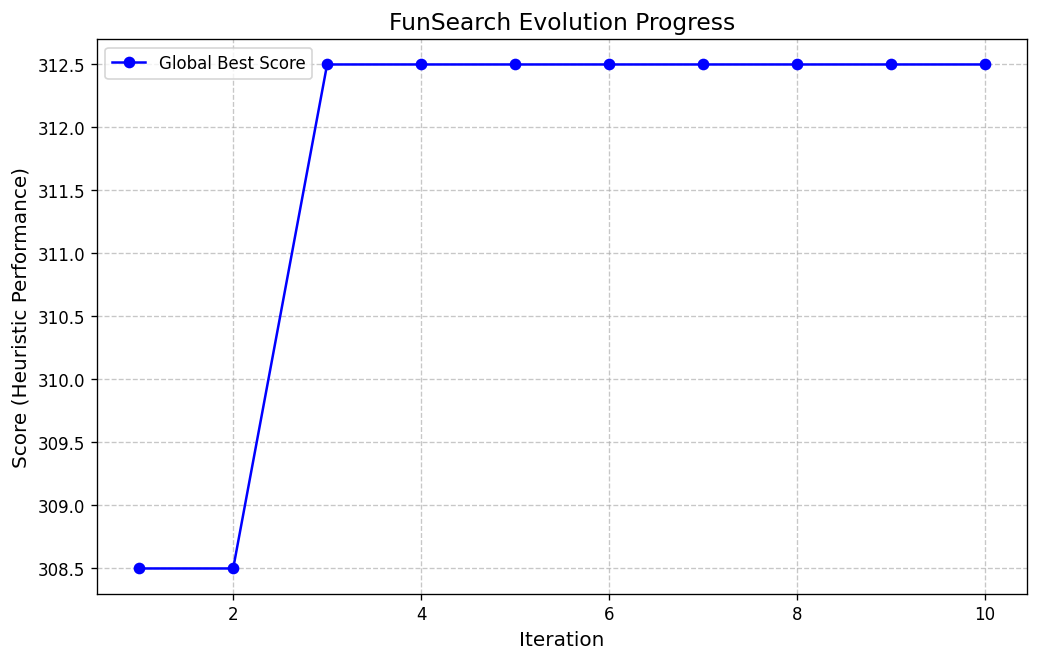

In [ ]:
import json
import matplotlib.pyplot as plt

# 1. 读取我们刚才保存的 JSON 数据
data_path = "/content/drive/MyDrive/FunSearch_enhancement/experiment_data.json"

try:
    with open(data_path, "r") as f:
        history = json.load(f)
except FileNotFoundError:
    print("实验数据文件还未生成，请确保 run.py 正在运行并且已经迭代了至少一次。")
    history = []

if history:
    # 2. 提取数据
    iterations = []
    global_best_scores = []

    for record in history:
        # 只提取有有效分数的数据（忽略 None / -inf）
        if record["global_best_score"] is not None:
            iterations.append(record["iteration"])
            global_best_scores.append(record["global_best_score"])

    # 3. 开始画图
    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(iterations, global_best_scores, marker='o', linestyle='-', color='b', label='Global Best Score')

    # 细节修饰
    plt.title("FunSearch Evolution Progress", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Score (Heuristic Performance)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # 4. 保存图片到 Google Drive
    plot_path = "/content/drive/MyDrive/FunSearch_enhancement/experiment_plot.png"
    plt.savefig(plot_path, bbox_inches='tight')
    print(f"✅ 图表已保存至: {plot_path}")

    # 在 Colab 中显示图表
    plt.show()